In [1]:
import argparse

from lloki.cae.run_lloki_cae import run_lloki_cae
from lloki.fp.run_lloki_fp import run_lloki_fp

import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import gdown

default_values = {
    'data_dir': "data/input_slices",
    'output_dir': "output",
    'model_dir': "external/scgpt",
    'reference_data_path': "data/reference_data/scref_full.h5ad",
    'k': 40,
    'iter': 40,
    'alpha': 0.5,
    'seed': 0,
    'device': "cpu",
    "npl_num_neighbors": 30
}

# Step 2: Convert the dictionary to an argparse.Namespace
args = argparse.Namespace(**default_values)

/Users/ioana/miniforge3/envs/lloki/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/Users/ioana/miniforge3/envs/lloki/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/Users/ioana/miniforge3/envs/lloki/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/Users/ioana/miniforge3/envs/lloki/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last

In [ ]:
data_dir = "data/input_slices"
data_parent_dir = os.path.dirname(data_dir)

# If the data_dir doesn't exist, download and extract
if not os.path.exists(data_dir):
    os.makedirs(data_parent_dir, exist_ok=True)

    zip_path = os.path.join(data_parent_dir, "h5ads_all.zip")
    gdown.download(id="1NE6SXmJcEKT4mhVMAO49-Y3KMCNoHOmM", output=zip_path, quiet=False)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_parent_dir)

    print(f"Unzipped into: {data_parent_dir}")
    
else:
    print(f"Found existing input slices: {data_dir}")

In [ ]:
# Download scGPT model assets if missing (vocab.json, checkpoints, etc.)
model_dir = args.model_dir

if not os.path.exists(model_dir):
    os.makedirs(os.path.dirname(model_dir), exist_ok=True)

    # Same folder used by `run_lloki.py`
    gdown.download_folder(
        url="https://drive.google.com/drive/u/0/folders/1wdVnQWJswC4haO7gOKWZP7AESp5z4kkB",
        output=os.path.dirname(model_dir),
        quiet=False,
    )

print("model_dir:", model_dir)
print("vocab exists:", os.path.exists(os.path.join(model_dir, "vocab.json")))

## Prepare large merfish data for LLoki

In [ ]:
import scanpy as sc
adata = sc.read_h5ad("data/reference_data/animal1_anterior_159genes.h5ad")

In [ ]:
import os
import json
import numpy as np
import scanpy as sc

out_dir = "data/input_slices"
os.makedirs(out_dir, exist_ok=True)

# Convert Ensembl -> symbol using the provided {symbol: ensembl} maps
with open("data/reference_data/merfish_symbol_to_ensembl.json", "r") as f:
    merfish_symbol_to_ens = json.load(f)
with open("data/reference_data/starmap_symbol_to_ensembl.json", "r") as f:
    starmap_symbol_to_ens = json.load(f)

ens_to_symbol = {v: k for k, v in {**merfish_symbol_to_ens, **starmap_symbol_to_ens}.items()}

keep_ranges = [
    (5770, 5780),
    (5780, 5790),
    (5790, 5800),
    (5800, 5810),
    (5810, 5820),
    (5820, 5830),
    (5830, 5840),
    (5840, 5850),
    (5850, 5860),
    (5860, 5870),
]

z = adata.obsm["X_CCF"][:, 2]
for z0, z1 in keep_ranges:
    mask = (z >= z0) & (z < z1)
    adata_slice = adata[mask].copy()

    # set spatial x,y from X_CCF
    adata_slice.obsm["spatial"] = adata_slice.obsm["X_CCF"][:, :2].copy()

    # rename Ensembl gene IDs -> symbols (leave untouched if not in map)
    adata_slice.var_names = [ens_to_symbol.get(g, g) for g in adata_slice.var_names]
    adata_slice.var_names_make_unique()

    out_path = os.path.join(out_dir, f"large_merfish_a1_{z0}.h5ad")
    adata_slice.write_h5ad(out_path)
    print(z0, z1, "cells:", adata_slice.n_obs, "->", out_path)

## Run lloki on data in input_slices

Processing file: data/input_slices/M500.h5ad
Starting Soft Feature Propagation...
Starting Soft Feature Propagation...
scGPT - INFO - match 473/500 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 939/939 [1:07:50<00:00,  4.34s/it]
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Clusters: 25, Resolution: 0.205


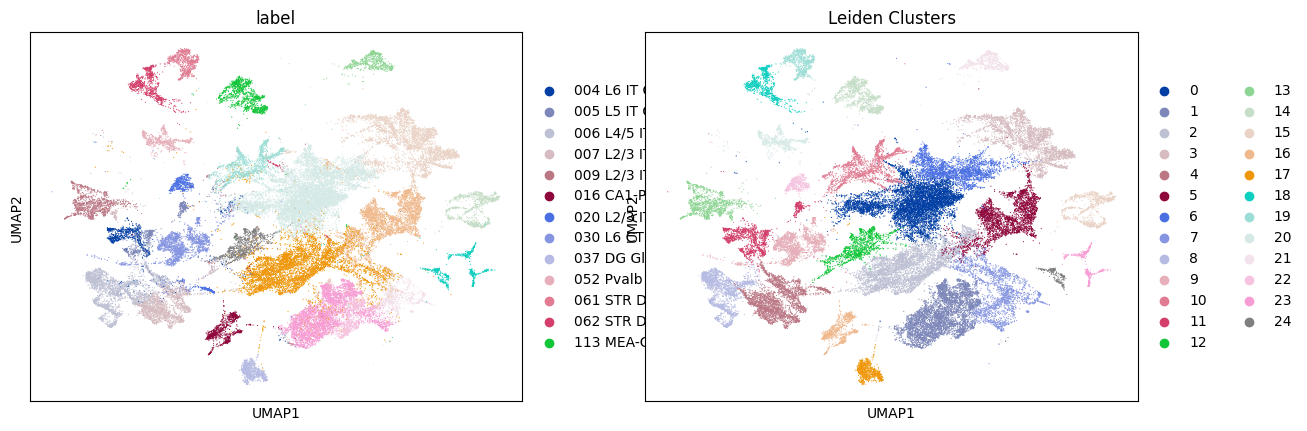

ARI: 0.679, NMI: 0.819, ASW: 0.159
Saved: output/M500_processed.h5ad
Score: None


<Figure size 640x480 with 0 Axes>

In [2]:
run_lloki_fp(args)

In [ ]:
starmap_slice_1_processed.h5ad,starmap_slice_2_processed.h5ad,starmap_slice_3_processed.h5ad,
starmap_slice_4_processed.h5ad,starmap_slice_5_processed.h5ad,starmap_slice_6_processed.h5ad,
starmap_slice_7_processed.h5ad,starmap_slice_8_processed.h5ad,starmap_slice_9_processed.h5ad

In [ ]:
default_values.update({
    "batch_dim": 10,
    "num_batches": 4,
    "lambda_neighborhood": 250,
    "lambda_triplet": 0.2,
    "lr": 5e-4,
    "epochs": 20,
    "batch_size": 4000,
})
args = argparse.Namespace(**default_values)

In [ ]:
run_lloki_cae(args)

## Only plot

In [ ]:
import os
import numpy as np
import scanpy as sc
import torch

from lloki.cae.run_lloki_cae import concatenate_anndata, prepare_data_for_training, evaluate_final
from lloki.cae.conditional_autoencoder import ConditionalAutoencoderML

# ---- settings ----
ckpt_path = "checkpoints/model_epoch20_ln250_lt0.2_lr0.0005_bd10_bs4000.pth"
device = torch.device("cpu")  # set "cuda" if you actually have it

output_dir = args.output_dir
num_batches = args.num_batches
batch_dim = args.batch_dim

# ---- rebuild the same data object (no training) ----
files = sorted([f for f in os.listdir(output_dir) if f.endswith(".h5ad")])
slices = [sc.read(os.path.join(output_dir, f)) for f in files]

batch_map = {
    "merfish": 0,
    "starmap": 1,
    "large": 2,
    "cosmx": 3,
    "m500": 4,
    "m1100": 5,
    "smp": 6,
    "xenium": 7,
}

for f, s in zip(files, slices):
    prefix = f.split("_", 1)[0].lower()
    if prefix not in batch_map:
        raise ValueError(f"Unknown prefix '{prefix}' for file '{f}'")
    s.obs["batch"] = batch_map[prefix]
    s.obs["batch_name"] = prefix

# remap batch ids to contiguous 0..(n-1) (required by embedding layer)
observed = sorted({int(b) for b in np.unique(np.concatenate([s.obs["batch"].values for s in slices]))})
if len(observed) != num_batches:
    raise ValueError(f"Found {len(observed)} unique batch ids {observed}, but num_batches={num_batches}.")
remap = {old: new for new, old in enumerate(observed)}
for s in slices:
    s.obs["batch_raw"] = s.obs["batch"]
    s.obs["batch"] = s.obs["batch"].map(remap).astype(int)

concat = concatenate_anndata(slices)
subset_indices = np.arange(concat.n_obs)
data = prepare_data_for_training(concat, subset_indices).to(device)

# ---- build model + load checkpoint (no training) ----
model = ConditionalAutoencoderML(
    enc_in_channels=512,
    batch_dim=batch_dim,
    latent_dim=128,
    hidden_dims=[256, 175],
    num_batches=num_batches,
).to(device)

state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model.eval()

# ---- encode + plot ----
adata_cae = evaluate_final(data, model, device, args)  # returns AnnData with embeddings in .X

# optional: nicer tech labels for plotting
contig_to_raw = {v: k for k, v in remap.items()}          # contiguous -> raw_id
inv_batch_map = {v: k for k, v in batch_map.items()}      # raw_id -> prefix name
adata_cae.obs["tech"] = (
    adata_cae.obs["batch"]
    .map(contig_to_raw)   # contiguous -> raw_id
    .map(inv_batch_map)   # raw_id -> name like "merfish", "xenium", ...
    .astype("category")
) # indices -> raw ids
# If you want names instead of ids:
inv_batch_map = {v: k for k, v in batch_map.items()}
adata_cae.obs["tech"] = adata_cae.obs["batch_raw"].map(inv_batch_map).astype("category")

import scanpy as sc
sc.pl.umap(adata_cae, color=["tech"])

In [3]:
import scanpy as sc

In [4]:
merfish1 = sc.read_h5ad("data/old_input_slices/merfish_slice_1.h5ad")
merfish2 = sc.read_h5ad("data/old_input_slices/merfish_slice_2.h5ad")
merfish3 = sc.read_h5ad("data/old_input_slices/merfish_slice_3.h5ad")
merfish4 = sc.read_h5ad("data/old_input_slices/merfish_slice_4.h5ad")
merfish5 = sc.read_h5ad("data/old_input_slices/merfish_slice_5.h5ad")


In [5]:
adata = merfish1.concatenate(merfish2, merfish3, merfish4, merfish5)

In [9]:
set(adata.obs["cell_class"])

{'Astrocyte',
 'Endothelial 1',
 'Endothelial 2',
 'Endothelial 3',
 'Ependymal',
 'Excitatory',
 'Inhibitory',
 'Microglia',
 'OD Immature 1',
 'OD Immature 2',
 'OD Mature 1',
 'OD Mature 2',
 'OD Mature 3',
 'OD Mature 4',
 'Pericytes'}

In [10]:
starmap1 = sc.read_h5ad("data/old_input_slices/starmap_slice_1.h5ad")
starmap2 = sc.read_h5ad("data/old_input_slices/starmap_slice_2.h5ad")
starmap3 = sc.read_h5ad("data/old_input_slices/starmap_slice_3.h5ad")
starmap4 = sc.read_h5ad("data/old_input_slices/starmap_slice_4.h5ad")
starmap5 = sc.read_h5ad("data/old_input_slices/starmap_slice_5.h5ad")
starmap6 = sc.read_h5ad("data/old_input_slices/starmap_slice_6.h5ad")
starmap7 = sc.read_h5ad("data/old_input_slices/starmap_slice_7.h5ad")
starmap8 = sc.read_h5ad("data/old_input_slices/starmap_slice_8.h5ad")
starmap9 = sc.read_h5ad("data/old_input_slices/starmap_slice_9.h5ad")


In [ ]:
adata = starmap1.concatenate(starmap2, starmap3, starmap4, starmap5, starmap6, starmap7, starmap8, starmap9)